In [4]:
import numpy  as np
import pandas as pd
import re,os,sys

In [5]:
path = r"LMD_PancreaticCancer_Quant_Spectranout_RAW_log2-mcpcounter-PDAC_sigmtx_allcelltypes_Joe.tsv"

In [6]:
data = pd.read_csv(path,sep="\t")

In [7]:
data

,Unnamed: 0,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
0,Acinar,1005.092824,876.901833,1054.878062,859.784021,1186.091734,1139.523157,1184.673284,1120.945292,1172.725016,...,1302.321471,1130.163241,1132.365180,1045.585478,1305.340963,1321.604265,953.363286,1334.941277,1316.325498,1265.132940
1,Activated_CD4,414.047798,379.732462,481.842811,408.452413,535.161538,476.103826,512.006455,461.613586,504.251477,...,514.708113,497.613589,474.450321,423.175558,487.950313,494.661137,375.245517,537.873516,532.065279,461.416518
2,B cell,769.086961,585.446389,828.756003,476.356766,689.561465,758.225473,689.421611,592.336709,679.380566,...,602.362007,612.430619,590.847956,504.315956,575.556562,611.389644,428.106554,853.776721,934.022532,702.159532
3,CD4,924.902085,815.950821,1007.175634,913.216201,1121.680311,942.674084,1080.756997,1018.533843,982.723424,...,1141.131566,862.953405,805.262928,606.954055,705.066767,754.056666,692.133352,877.645468,883.175499,770.285923
4,CD8,327.633060,287.469837,387.539442,300.714450,429.823497,390.998798,417.244788,339.562926,419.458614,...,410.108475,430.941914,406.727054,371.149209,422.745384,434.361433,290.634865,466.717623,463.791141,387.833189
5,Effector_CD8,205.582327,207.660189,239.196011,229.389162,269.680309,234.962032,288.532596,223.644923,281.727525,...,281.254354,244.953010,233.873083,217.091289,235.040795,237.075265,178.589962,247.230759,260.503672,212.801012
6,Endocrine,1341.023989,1096.551097,1465.756443,970.053448,1383.745212,1445.269115,1331.575037,1272.868367,1148.943030,...,1273.228039,1328.837613,1271.127374,1033.592265,1390.816961,1394.603632,987.640315,1555.763203,1586.277795,1383.426335
7,Endothelial,550.069317,495.689858,578.386141,452.162497,649.226405,603.618809,619.158182,594.150211,594.701559,...,567.379977,483.355313,477.477691,491.967317,607.250776,590.464703,454.837131,601.020433,635.049913,551.332021
8,Epithelial_cancer,1132.641750,969.639869,1178.695159,995.662968,1363.227232,1267.357478,1309.089143,1289.602941,1340.263143,...,1470.478576,1408.166709,1416.373882,1011.987816,1297.696669,1336.626133,1017.783210,1248.510767,1253.539625,1193.155368
9,Epithelial_normal,1005.301602,902.661457,1049.999803,891.492501,1243.700158,1194.659484,1218.492943,1160.562095,1191.969061,...,1336.981934,1285.795837,1279.174754,1163.618148,1378.345687,1406.762657,987.154826,1452.496544,1464.389403,1370.338512


In [8]:
df = pd.DataFrame(data).set_index("Unnamed: 0") 

df_percentage = df.div(df.sum(axis=0), axis=1) * 100

In [9]:
df_percentage

,400_PDAC_1,400_PDAC_2,400_PDAC_3,400_PDAC_4,400_PDAC_5,400_PDAC_6,400_PDAC_7,400_PDAC_8,008_PDAC_1,008_PDAC_2,...,628_IPMN_3,400_NAT_1,400_NAT_2,400_NAT_3,175_NAT_1,175_NAT_2,175_NAT_3,504_NAT_1,504_NAT_2,504_NAT_3
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Acinar,7.703364,7.747472,7.528977,7.680979,7.731234,7.671525,7.862460,7.631389,8.185413,8.428895,...,8.869260,8.261208,8.398251,8.547304,8.814111,8.878897,8.275649,8.309343,8.265844,8.558511
Activated_CD4,3.173399,3.354956,3.439055,3.648956,3.488313,3.205238,3.398093,3.142663,3.519586,3.620254,...,3.505340,3.637430,3.518788,3.459316,3.294808,3.323268,3.257310,3.347994,3.341095,3.121441
B cell,5.894537,5.172449,5.915077,4.255588,4.494729,5.104544,4.575565,4.032625,4.741956,4.108318,...,4.102294,4.476713,4.382058,4.122611,3.886356,4.107482,3.716169,5.314334,5.865179,4.750046
CD4,7.088756,7.208967,7.188511,8.158321,7.311384,6.346293,7.172787,6.934173,6.859236,5.055071,...,7.771501,6.307972,5.972279,4.961642,4.760853,5.065958,6.008048,5.462905,5.545886,5.210915
CD8,2.511088,2.539811,2.765984,2.686467,2.801694,2.632292,2.769177,2.311743,2.927747,3.215795,...,2.792981,3.150077,3.016515,3.034018,2.854522,2.918158,2.522849,2.905084,2.912369,2.623657
Effector_CD8,1.575651,1.834688,1.707213,2.049274,1.757842,1.581817,1.914938,1.522573,1.966408,1.934534,...,1.915439,1.790545,1.734533,1.774647,1.587076,1.592736,1.550246,1.538888,1.635829,1.439580
Endocrine,10.278052,9.688085,10.461538,8.666083,9.019587,9.729876,8.837420,8.665681,8.019419,8.315345,...,8.671123,9.713468,9.427389,8.449264,9.391274,9.369326,8.573190,9.683850,9.961005,9.358755
Endothelial,4.215913,4.379445,4.128113,4.039445,4.231815,4.063697,4.109240,4.044971,4.150912,4.457463,...,3.864054,3.533205,3.541241,4.021665,4.100366,3.966902,3.948204,3.741052,3.987785,3.729712
Epithelial_cancer,8.680941,8.566817,8.412697,8.894869,8.885846,8.532135,8.688185,8.779610,9.354800,10.644807,...,10.014468,10.293343,10.504618,8.272655,8.762494,8.979818,8.834845,7.771357,7.871581,8.071589


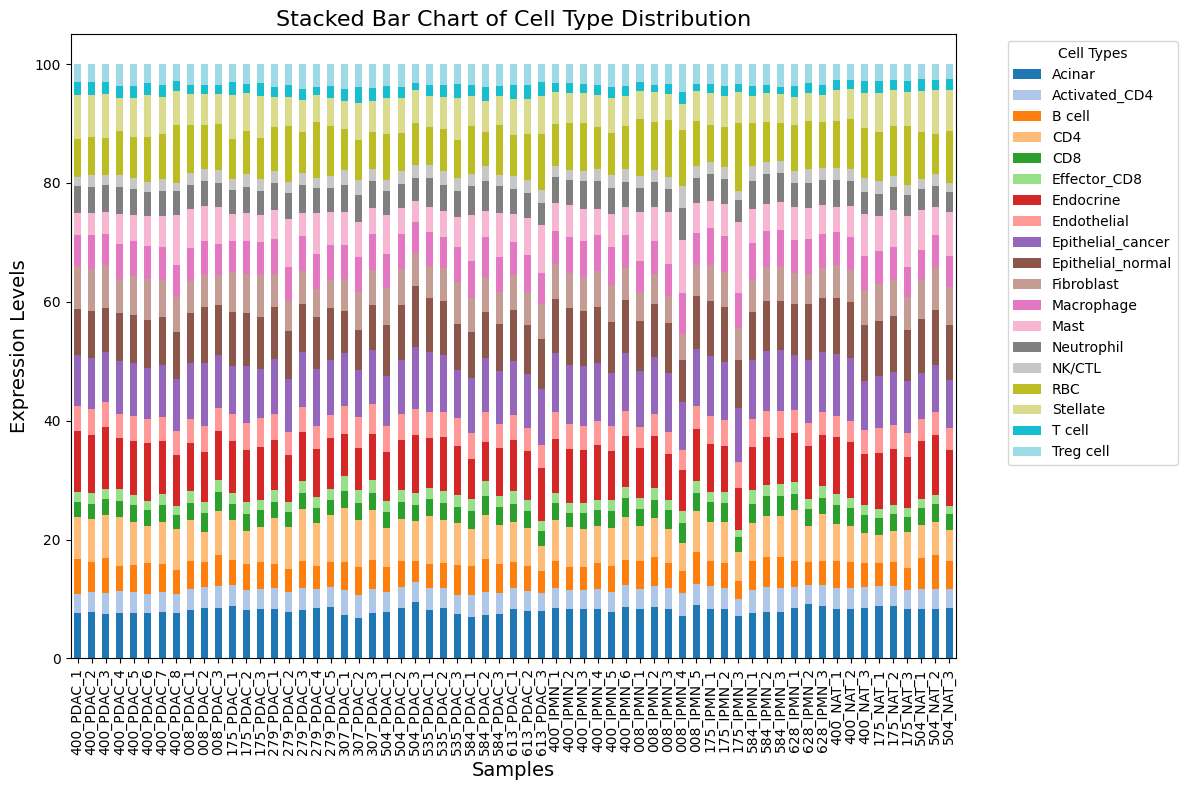

In [10]:
# Convert to a DataFrame
import matplotlib.pyplot as plt


# Create a stacked bar chart
df_percentage.T.plot(kind="bar", stacked=True, figsize=(12, 8), colormap="tab20")
plt.title("Stacked Bar Chart of Cell Type Distribution", fontsize=16)
plt.xlabel("Samples", fontsize=14)
plt.ylabel("Expression Levels", fontsize=14)
plt.legend(title="Cell Types", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
# Assuming `df_percentage` contains your percentage-normalized data
pca = PCA(n_components=2)  # Choose the number of components you want
pca_result = pca.fit_transform(df_percentage.T)  # Transpose to analyze samples


In [13]:
pca_df = pd.DataFrame(
    pca_result, columns=['PC1', 'PC2'], index=df_percentage.columns
)


In [14]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance: {explained_variance}")


Explained Variance: [0.46161655 0.21390081]


In [16]:
pca_df.head(2)

,PC1,PC2
400_PDAC_1,-3.223577,1.956713
400_PDAC_2,-2.817398,1.355034


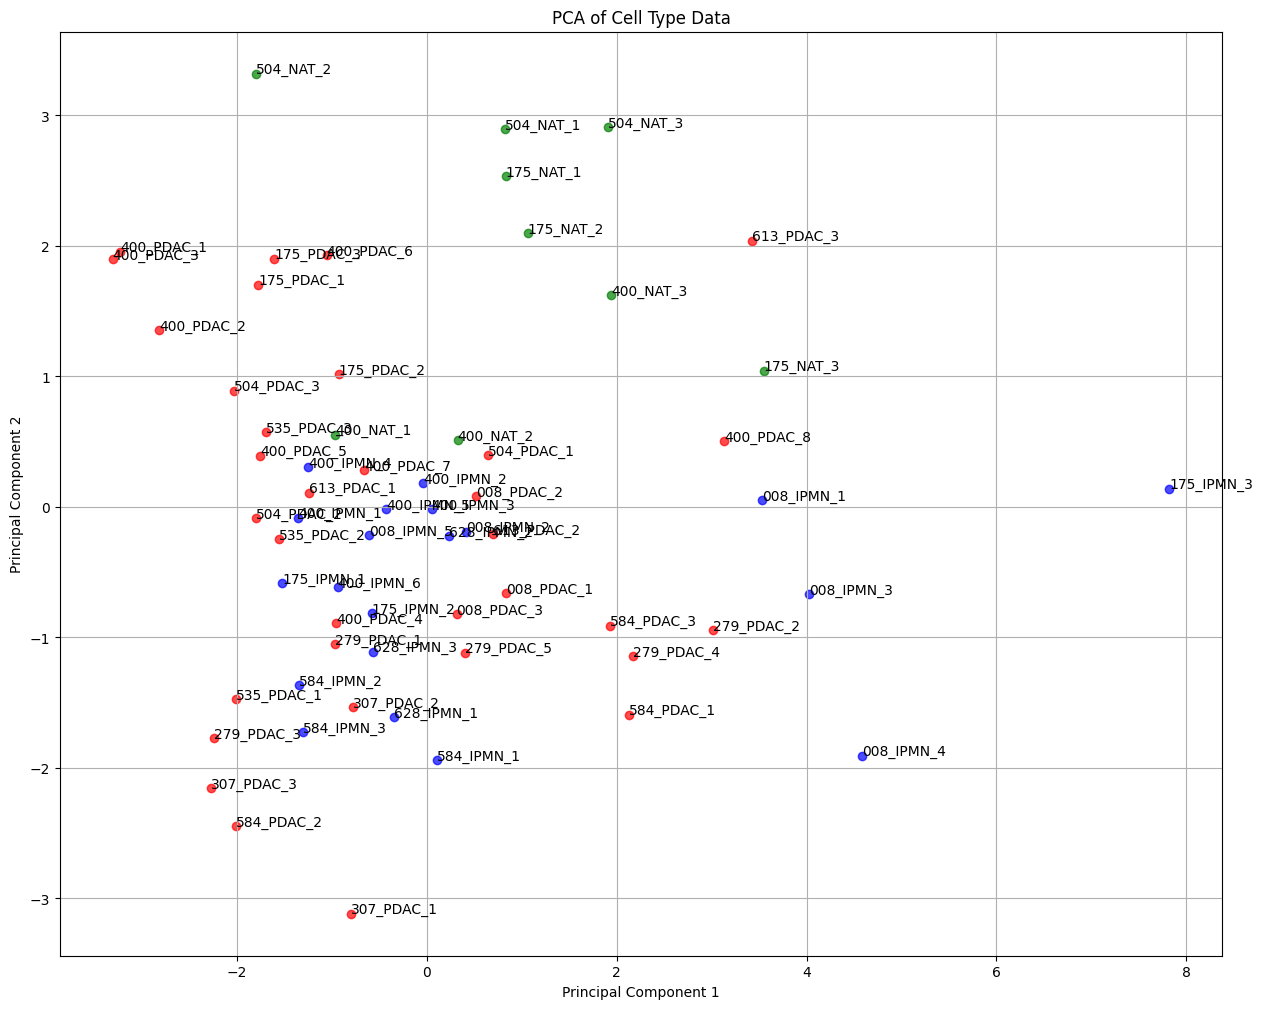

In [23]:
plt.figure(figsize=(15, 12))
plt.scatter(pca_df[pca_df.index.str.contains('PDAC')]['PC1'], pca_df[pca_df.index.str.contains('PDAC')]['PC2'], c='red', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('IPMN')]['PC1'], pca_df[pca_df.index.str.contains('IPMN')]['PC2'], c='blue', alpha=0.7)
plt.scatter(pca_df[pca_df.index.str.contains('NAT')]['PC1'], pca_df[pca_df.index.str.contains('NAT')]['PC2'], c='green', alpha=0.7)
for sample, (x, y) in pca_df.iterrows():
    plt.text(x, y, sample, fontsize=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Cell Type Data')
plt.grid()
plt.show()


In [19]:
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose to align features with PCs
    index=df_percentage.index,  # Feature names (cell types)
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]  # PC names
)
print(loadings)


                        PC1       PC2
Unnamed: 0                           
Acinar            -0.031921  0.127559
Activated_CD4     -0.044642 -0.134838
B cell            -0.145474  0.045324
CD4               -0.271267 -0.441010
CD8               -0.012249 -0.069882
Effector_CD8      -0.043788 -0.106332
Endocrine         -0.146097  0.454578
Endothelial       -0.084922 -0.062363
Epithelial_cancer -0.016198 -0.197359
Epithelial_normal -0.028842  0.196137
Fibroblast        -0.164148  0.295961
Macrophage        -0.008959 -0.156730
Mast               0.748066 -0.003465
Neutrophil        -0.064931 -0.196025
NK/CTL             0.001930 -0.093981
RBC                0.506885  0.093402
Stellate          -0.146843  0.480166
T cell            -0.030133  0.024853
Treg cell         -0.016466 -0.255997


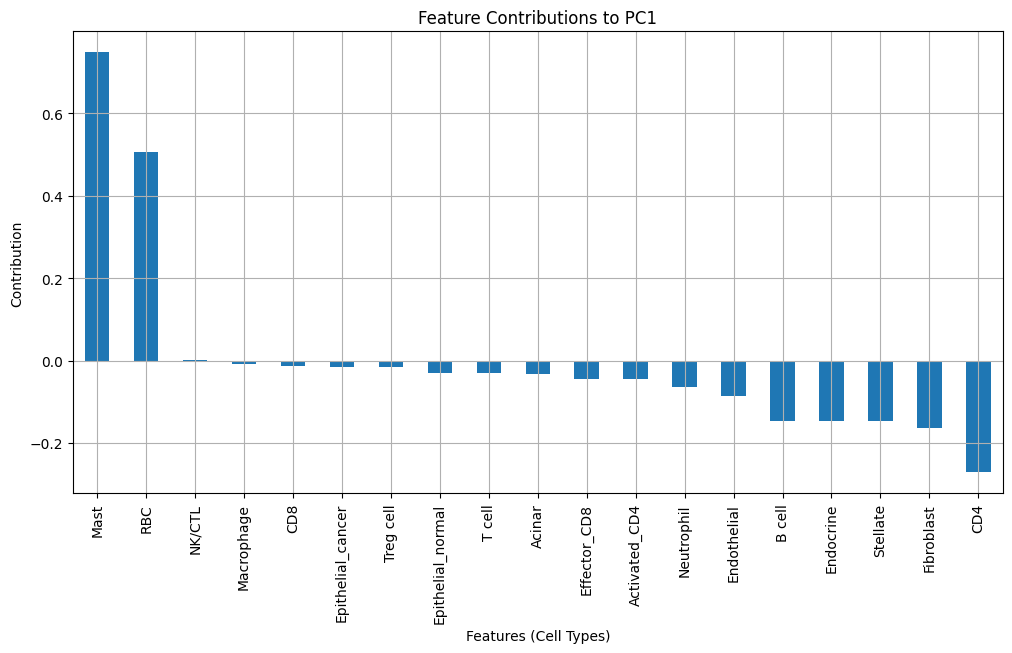

In [20]:
plt.figure(figsize=(12, 6))
loadings['PC1'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC1')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()


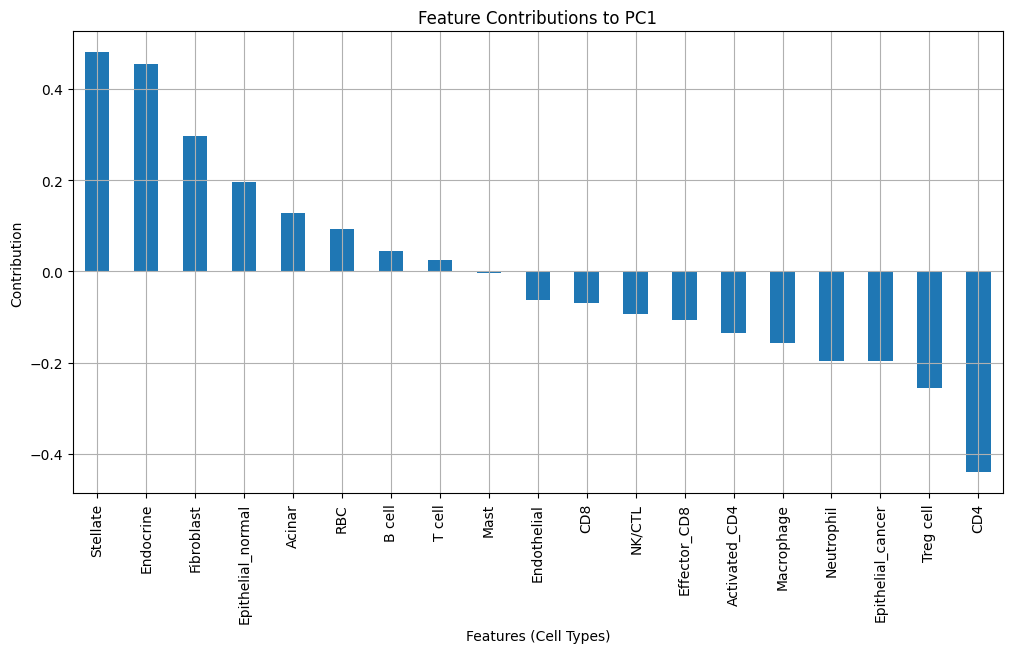

In [22]:
plt.figure(figsize=(12, 6))
loadings['PC2'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Contributions to PC1')
plt.xlabel('Features (Cell Types)')
plt.ylabel('Contribution')
plt.grid()
plt.show()

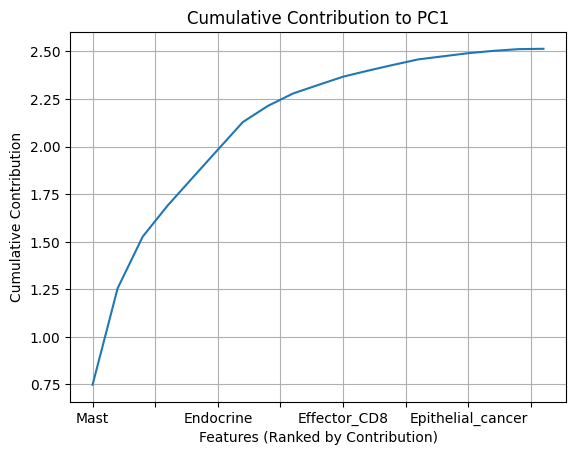

In [21]:
loadings['PC1'].abs().sort_values(ascending=False).cumsum().plot()
plt.title('Cumulative Contribution to PC1')
plt.xlabel('Features (Ranked by Contribution)')
plt.ylabel('Cumulative Contribution')
plt.grid()
plt.show()
